# 1. Introduction

Accurately predicting housing prices is a central problem in real estate, with important implications for buyers, sellers, and investors. Housing markets are influenced by a wide range of factors, including location, property characteristics, and broader economic conditions, making price estimation a complex and data-driven task.

In this essay, we explore how machine learning techniques can be used to predict housing prices based on structured data. Using a dataset containing features such as square footage, number of bedrooms, and neighborhood characteristics, we investigate how different variables contribute to price variation, we'll build an XGBoost model to estimate property values.

This analysis is for the Kaggle competition, "House Prices - Advanced Regression Techniques," and we will be using the data provided on the [competition website](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data).

We begin by performing exploratory data analysis to understand the structure and relationships within the dataset. We then implement and fine-tune a model to predict housing prices as accurately as possible. Finally, we analyze the strengths and limitations of our model and discuss potential improvements.

Through this process, the essay demonstrates how computational methods can be applied to a real-world problem, highlighting both the power and challenges of predictive modeling in housing markets.

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Data Preprocessing

## 2.1. Initial Glance

We should first take a look at what our data looks like, and what each column means.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('train.csv')
data.head(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


Since each house is labeled with a unique ID number, we will just use that as the index for our dataframe to simplify identification of rows.

In [5]:
data.set_index(data['Id'],inplace=True)
del data['Id']
data.head(10)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900


## 2.2. Missing Data

Although we will be implementing a model that does not require data imputation, it is insightful for us to get an idea of what we data are missing.

In [6]:
for column in data.columns:
    num_missing = data[column].isnull().sum()
    if num_missing:
        print(f"{column} Missing Values: {num_missing}")

LotFrontage Missing Values: 259
Alley Missing Values: 1369
MasVnrType Missing Values: 872
MasVnrArea Missing Values: 8
BsmtQual Missing Values: 37
BsmtCond Missing Values: 37
BsmtExposure Missing Values: 38
BsmtFinType1 Missing Values: 37
BsmtFinType2 Missing Values: 38
Electrical Missing Values: 1
FireplaceQu Missing Values: 690
GarageType Missing Values: 81
GarageYrBlt Missing Values: 81
GarageFinish Missing Values: 81
GarageQual Missing Values: 81
GarageCond Missing Values: 81
PoolQC Missing Values: 1453
Fence Missing Values: 1179
MiscFeature Missing Values: 1406


We notice a large number of missing values in columns `Alley`, `PoolQC`, `Fence`, and `MiscFeatures`. 

- `Alley`: Type of alley access
- `PoolQC`: Pool quality
- `Fence`: Fence quality
- `MiscFeatures`: $Value of miscellaneous feature

It would make sense that some of these columns don't have much data. For example, pool quality and fence quality will be missing for houses without a pool. Similarly, not all houses have alleys and miscellaneous features.

## 2.3. Encoding Data

There are many categorical variables in our dataset, which we will need to encode to a numeric value for our model to intepret. However, we will not worry about it yet because we will set XGBoost's `enable_categorical` parameter to `True` to handle both ordinal and cardinal categorical variables. This feature in XGBoost automatically decides how to encode categorical variables using either label or one-hot encoding depending on the number of categories. It uses an algorithm called "optimal partitioning" which finds the best grouping of categories at each split, which is often better than manual encoding. 

# 3. Feature Engineering

## 3.1. Features Function
We will implement some additional features to help our model learn. Additionally, we'll get rid of outliers.

One of the most important features in this dataset is the neighborhood. We will engineer extra features around this to give tiers to the neighborhood. This function can be found in `feature_engineering.py`

In [7]:
from feature_engineering import engineer_features

## 3.2. Missing Data Function

We will need to deal with the fact that some data in our validation data won't appear in our training data. Therefore, we need to remove those missing values or else our model will be skewed. This function can also be found in `feature_engineering.py`

In [8]:
from feature_engineering import fill_missing

# 4. Creating our XGBoost Model

## 4.1. Splitting Data

We will split our data into training and testing with a 80/20 split. We will also split the data randomly for validation purposes. We will also take $\log(1+y)$ so that we are minimizing our model for RMSLE. We will also need to convert our categorical variables to Pandas' `category` type.

In [9]:
from sklearn.model_selection import train_test_split

# ── columns confirmed as zero importance or redundant ────────────────────────
drop_cols = [
    # zero importance
    "HasGarage", "HasFireplace", "Has2ndFloor", "HasBasement", "HasPool",
    "IsNewHouse", "Is1pt5Story", "3SsnPorch", "LowQualFinSF", "Condition2",
    "Heating", "Street", "Utilities", "PoolQC", "PoolArea",
    "MiscFeature", "BsmtHalfBath", "Alley",
    
    # redundant — correlated >0.99 with engineered versions
    "YearBuilt",     # replaced by HouseAge
    "GarageYrBlt",   # replaced by GarageAge
    "YearRemodAdd",  # replaced by RemodAge
]

# ── remove outliers ───────────────────────────────────────────────────────────
data = data[~((data["GrLivArea"] > 4000) & (data["SalePrice"] < 200000))]
abnormal_mask = (data["SaleCondition"] == "Abnorml") & \
                ((data["SalePrice"] < 50000) | (data["SalePrice"] > 500000))
data = data[~abnormal_mask]

X = data.drop(["SalePrice"], axis=1)
y = np.log1p(data["SalePrice"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── feature engineering then null fill ───────────────────────────────────────
X_train = engineer_features(X_train)
X_test  = engineer_features(X_test)

X_train = fill_missing(X_train)
X_test  = fill_missing(X_test)

# move drop_cols to section 4.1 so ALL models use the same features
X_train = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_test  = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])

# ── cast to category ──────────────────────────────────────────────────────────
cat_cols = X_train.select_dtypes(include=["object", "str"]).columns
X_train[cat_cols] = X_train[cat_cols].astype("category")
for col in cat_cols:
    train_cats = X_train[col].cat.categories
    X_test[col] = X_test[col].astype("category").cat.set_categories(train_cats)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (1163, 142)
X_test shape:  (291, 142)


## 4.2. Initial Model

Now we will create our initial XGBoost model with basic parameters. We will implement techniques such as early stopping, subsampling, regularization, etc. to reduce the chance of overfitting.

In [10]:
import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.metrics import root_mean_squared_error

model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="rmse",
    random_state=42,
    early_stopping_rounds=30,
    min_child_weight=10,
    gamma=0.05,
    reg_alpha=0.05,
    reg_lambda=1.0,
    enable_categorical = True
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

# make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# evaluate
train_rmse = root_mean_squared_error(y_train, y_train_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

print(f"Training RMSE: {train_rmse:.5f}")
print(f"Testing RMSE: {test_rmse:.5f}")

[0]	validation_0-rmse:0.38959
[100]	validation_0-rmse:0.11990
[199]	validation_0-rmse:0.11935
Training RMSE: 0.06904
Testing RMSE: 0.11929


## 4.3. Hyperparameter Tuning

With our initial model completed, we will need to move into hyperparameter tuning. For this step, we will use Optuna to help us find the best hyperparameters. We will also build in cross-validation into our training process to ensure that if our model is overfit, there's evidence to suggest that it is helpful memorization.

In [11]:
import optuna
from sklearn.model_selection import StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING) # stop printing every result

def objective(trial):
    params = {
        "objective":          "reg:squarederror",
        "learning_rate":      trial.suggest_float("learning_rate",    0.01,  0.05, log=True),
        "max_depth":          trial.suggest_int(  "max_depth",        2,     8),
        "subsample":          trial.suggest_float("subsample",        0.6,   1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.6,   1.0),
        "min_child_weight":   trial.suggest_int(  "min_child_weight", 1,     20),
        "gamma":              trial.suggest_float("gamma",            0,     1.0),
        "reg_alpha":          trial.suggest_float("reg_alpha",        0.01,  2.5,  log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda",       0.01,  2.5,  log=True),
        "n_estimators":       5000,
        "early_stopping_rounds": 50,
        "eval_metric":        "rmse",
        "random_state":       42,
        "enable_categorical": True,
    }

    price_buckets = pd.qcut(y_train, q=10, labels=False)
    skf           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof           = np.zeros(len(X_train))

    for train_idx, val_idx in skf.split(X_train, price_buckets):
        X_tr  = X_train.iloc[train_idx].copy()
        X_val = X_train.iloc[val_idx].copy()
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # ── same neighbourhood encoding as cross_validate_xgb_stratified ─────
        nbr_mean = y_tr.groupby(X_tr["Neighborhood"].astype(str)).mean()
        nbr_std  = y_tr.groupby(X_tr["Neighborhood"].astype(str)).std()
        nbr_cov  = nbr_std / nbr_mean

        X_tr["Nbr_MeanPrice"]       = X_tr["Neighborhood"].astype(str).map(nbr_mean)
        X_val["Nbr_MeanPrice"]      = X_val["Neighborhood"].astype(str).map(nbr_mean).fillna(y_tr.mean())
        X_tr["Nbr_StdPrice"]        = X_tr["Neighborhood"].astype(str).map(nbr_std)
        X_val["Nbr_StdPrice"]       = X_val["Neighborhood"].astype(str).map(nbr_std).fillna(y_tr.std())
        X_tr["Nbr_CoV"]             = X_tr["Neighborhood"].astype(str).map(nbr_cov)
        X_val["Nbr_CoV"]            = X_val["Neighborhood"].astype(str).map(nbr_cov).fillna(nbr_cov.mean())
        X_tr["QualStdInteraction"]  = X_tr["OverallQual"] * X_tr["Nbr_StdPrice"]
        X_val["QualStdInteraction"] = X_val["OverallQual"] * X_val["Nbr_StdPrice"]
        X_tr["SFStdInteraction"]    = X_tr["TotalSF"]     * X_tr["Nbr_StdPrice"]
        X_val["SFStdInteraction"]   = X_val["TotalSF"]    * X_val["Nbr_StdPrice"]

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        oof[val_idx] = model.predict(X_val)

    return root_mean_squared_error(y_train, oof)


xgb_study = optuna.create_study(direction="minimize")
xgb_study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest OOF RMSE:  {xgb_study.best_value:.5f}")
print(f"Best params:    {xgb_study.best_params}")

c:\Users\yongg\OneDrive\Desktop\studying\Coding Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 16. Best value: 0.115148: 100%|██████████| 50/50 [03:32<00:00,  4.25s/it]


Best OOF RMSE:  0.11515
Best params:    {'learning_rate': 0.01436269431101421, 'max_depth': 7, 'subsample': 0.8460838927352802, 'colsample_bytree': 0.9116655984545992, 'min_child_weight': 20, 'gamma': 0.00014553429533477265, 'reg_alpha': 0.0813556137153366, 'reg_lambda': 0.015382552544013064}


# 5. Model Validation

## 5.1. Stratified K-Folds Cross Validation

In [12]:
from model_validation import cross_validate_xgb_stratified

xgb_params = xgb_study.best_params

xgb_params = {
    **xgb_params,
    "objective":   "reg:squarederror",
    "eval_metric": "rmse",
    "random_state": 42,
}

# ── Run XGBoost ───────────────────────────────────────────────────────────────
xgb_models, xgb_oof, xgb_fold_scores = cross_validate_xgb_stratified(
    X_train, y_train,
    xgb_params,
    n_splits=5,
    n_estimators=7000,
    early_stopping_rounds=30
)


--- Fold 1 / 5 ---
[0]	validation_0-rmse:0.38295
[100]	validation_0-rmse:0.16625
[200]	validation_0-rmse:0.13227
[300]	validation_0-rmse:0.12464
[400]	validation_0-rmse:0.12177
[500]	validation_0-rmse:0.12058
[600]	validation_0-rmse:0.12014
[651]	validation_0-rmse:0.12005
Fold 1 RMSE: 0.12002 | Best iteration: 621

--- Fold 2 / 5 ---
[0]	validation_0-rmse:0.39373
[100]	validation_0-rmse:0.17071
[200]	validation_0-rmse:0.12967
[300]	validation_0-rmse:0.11975
[400]	validation_0-rmse:0.11667
[500]	validation_0-rmse:0.11528
[600]	validation_0-rmse:0.11421
[700]	validation_0-rmse:0.11396
[800]	validation_0-rmse:0.11348
[864]	validation_0-rmse:0.11336
Fold 2 RMSE: 0.11329 | Best iteration: 834

--- Fold 3 / 5 ---
[0]	validation_0-rmse:0.38970
[100]	validation_0-rmse:0.16234
[200]	validation_0-rmse:0.12953
[300]	validation_0-rmse:0.12393
[400]	validation_0-rmse:0.12237
[500]	validation_0-rmse:0.12165
[600]	validation_0-rmse:0.12115
[700]	validation_0-rmse:0.12085
[720]	validation_0-rmse:0.12

## 5.2. Error Analysis

We'll take a look at the houses that produce the most error and their properties to analyze what needs improvement in our model.

### Find Largest Percent Errors

In [13]:
# find which houses have the worst OOF predictions
oof_errors = pd.DataFrame({
    "actual":    np.expm1(y_train),
    "predicted": np.expm1(xgb_oof),
    "error":     np.abs(np.expm1(y_train) - np.expm1(xgb_oof)),
    "pct_error": np.abs(np.expm1(y_train) - np.expm1(xgb_oof)) / np.expm1(y_train)
}, index=X_train.index)

worst = oof_errors.nlargest(20, "pct_error")
print(worst)

        actual      predicted          error  pct_error
Id                                                     
633    82500.0  172302.305055   89802.305055   1.088513
1325  147000.0  293662.249538  146662.249538   0.997702
411    60000.0  106994.146189   46994.146189   0.783236
534    39300.0   68177.772011   28877.772011   0.734803
1454   84500.0  140040.656770   55540.656770   0.657286
1433   64500.0  101666.290908   37166.290908   0.576222
875    66500.0  103037.907487   36537.907487   0.549442
67    180000.0  276327.460774   96327.460774   0.535153
589   143000.0  215740.564504   72740.564504   0.508675
432    79900.0  118835.283067   38935.283067   0.487300
1063   90000.0  132688.212297   42688.212297   0.474313
692   755000.0  418266.818375  336733.181625   0.446004
971   135000.0   78801.963802   56198.036198   0.416282
715   130500.0  183035.033415   52535.033415   0.402567
1384  112000.0  156297.693064   44297.693064   0.395515
667   129000.0  179121.497674   50121.497674   0

### Find Commonalities Between Inaccurate Predictions

In [14]:
# check which features the worst houses have in common
print(X_train.loc[worst.index, ["Neighborhood", "BldgType", 
                                 "HouseStyle", "OverallQual", 
                                 "TotalSF"]].to_string())

     Neighborhood BldgType HouseStyle  OverallQual   TotalSF
Id                                                          
633        NWAmes     1Fam     1Story            7  7.936660
1325      Somerst     1Fam     1Story            8  8.186186
411       Edwards     1Fam     1Story            5  7.845024
534       BrkSide     1Fam     1Story            1  5.814131
1454      Mitchel     1Fam     1Story            5  7.732369
1433      OldTown     1Fam     1Story            4  7.393263
875       OldTown     1Fam     1.5Fin            5  7.499977
67          NAmes     1Fam     1Story            7  8.332068
589       ClearCr     1Fam     1Story            5  7.976252
432       OldTown     1Fam     1.5Fin            6  7.649693
1063      OldTown   2fmCon     2Story            5  8.006368
692       NoRidge     1Fam     2Story           10  8.818926
971         NAmes     1Fam     1.5Fin            4  7.556428
715        Sawyer     1Fam     2Story            6  7.698483
1384       Sawyer     1F

In [15]:
investigate_ids = [633, 1325, 411, 589, 1454, 1280, 1132, 480]

check_cols = [
    "SaleCondition", "SaleType", "Functional",
    "OverallCond", "ExterCond", "BsmtCond", "BsmtExposure",
    "MSSubClass", "LotArea", "LotConfig", "LotShape",
    "Neighborhood", "BldgType", "HouseStyle",
    "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd",
    "GarageType", "GarageCars", "WoodDeckSF",
    "MoSold", "YrSold", "SalePrice"
]

print(data.loc[data.index.isin(investigate_ids), check_cols].to_string())

# look at every single feature for id 633
print(data.loc[633].to_string())

     SaleCondition SaleType Functional  OverallCond ExterCond BsmtCond BsmtExposure  MSSubClass  LotArea LotConfig LotShape Neighborhood BldgType HouseStyle  BedroomAbvGr  KitchenAbvGr  TotRmsAbvGrd GarageType  GarageCars  WoodDeckSF  MoSold  YrSold  SalePrice
Id                                                                                                                                                                                                                                                                  
411        Abnorml      COD        Mod            3        Fa       Fa           No          20     9571    Inside      Reg      Edwards     1Fam     1Story             3             1             5     Attchd           1           0       6    2009      60000
480         Alloca       WD        Typ            7        TA       TA           No          30     5925    Inside      Reg      OldTown     1Fam     1Story             2             1             7     Detchd        

These houses constantly reappear despite new features and hyperparameter tuning, so we will choose to make a new model to ensemble with.

# 6. Visualizations for Model

## 6.1. Most Important Features

To reduce the "black-box" feeling of our model, we can see what our model deemed the most important features for regression.

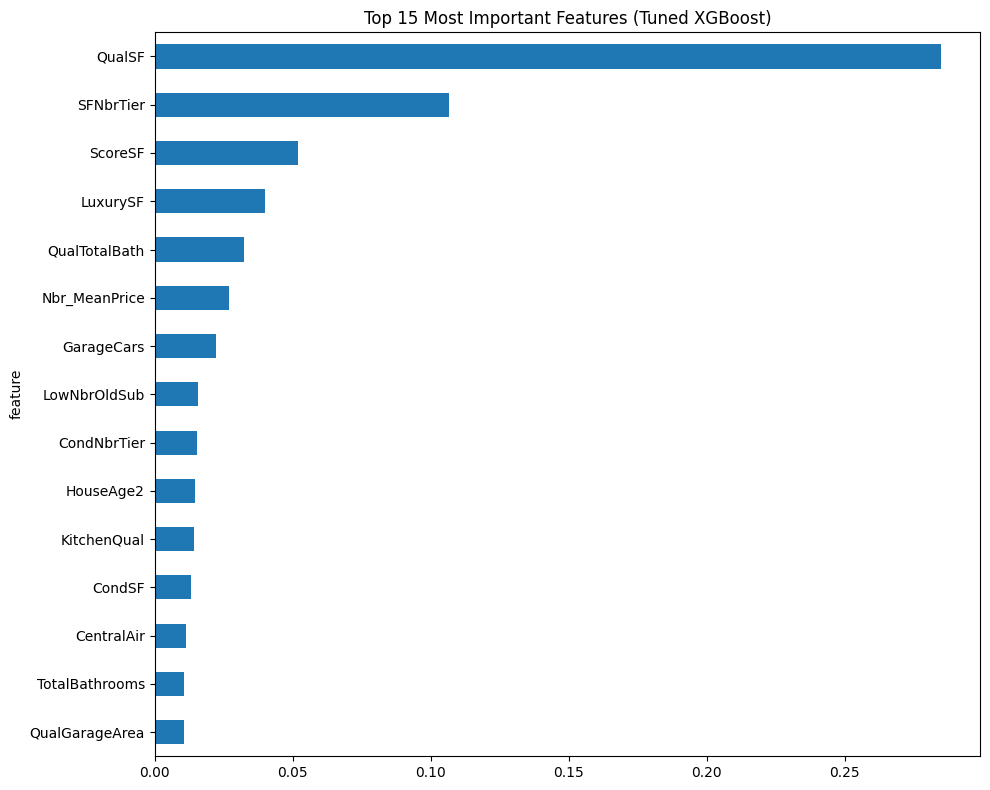

In [16]:
importance_df = pd.DataFrame()
for model, nbr_mean, nbr_std, nbr_cov in xgb_models:
    imp = pd.DataFrame({
        "feature":    model.feature_names_in_,
        "importance": model.feature_importances_
    })
    importance_df = pd.concat([importance_df, imp])

avg_importance = (importance_df
                  .groupby("feature")["importance"]
                  .mean()
                  .sort_values(ascending=False)
                  .reset_index())

fig, ax = plt.subplots(figsize=(10, 8))
avg_importance.head(15).plot.barh(x="feature", y="importance", ax=ax, legend=False)
ax.set_title("Top 15 Most Important Features (Tuned XGBoost)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# 7. LGBM Model

We will use another gradient boosting model to ensemble with our XGBoost model to hopefully fix some of the errors of our first model.

## 7.1. Hyperparameter Tuning

In [17]:
import lightgbm as lgb

def lgb_objective(trial):
    params = {
        # ── tree structure ─────────────────────────────────────────────────────
        "num_leaves":       trial.suggest_int(  "num_leaves",       20,   150), 
        "max_depth":        trial.suggest_int(  "max_depth",        3,    8),
        "min_child_samples":trial.suggest_int(  "min_child_samples",10,   100),       

        # ── sampling ───────────────────────────────────────────────────────────
        "learning_rate":    trial.suggest_float("learning_rate",    0.01, 0.1,  log=True),
        "subsample":        trial.suggest_float("subsample",        0.5,  0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5,  0.9),
        "subsample_freq":   1,                                 

        # ── regularisation ─────────────────────────────────────────────────────
        "reg_alpha":        trial.suggest_float("reg_alpha",        0.01, 2.0,  log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda",       0.01, 2.0,  log=True),
        "min_split_gain":   trial.suggest_float("min_split_gain",   0.0,  1.0),    

        # ── fixed params ───────────────────────────────────────────────────────
        "objective":        "regression",
        "metric":           "rmse",
        "verbose":          -1,
        "n_jobs":           -1,
    }

    from sklearn.model_selection import StratifiedKFold
    price_buckets = pd.qcut(y_train, q=10, labels=False)
    skf           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof           = np.zeros(len(X_train))

    for train_idx, val_idx in skf.split(X_train, price_buckets):
        X_tr  = X_train.iloc[train_idx].copy()
        X_val = X_train.iloc[val_idx].copy()
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # ── neighbourhood encoding (same as XGBoost) ──────────────────────────
        nbr_mean = y_tr.groupby(X_tr["Neighborhood"].astype(str)).mean()
        nbr_std  = y_tr.groupby(X_tr["Neighborhood"].astype(str)).std()
        nbr_cov  = nbr_std / nbr_mean

        X_tr["Nbr_MeanPrice"]       = X_tr["Neighborhood"].astype(str).map(nbr_mean)
        X_val["Nbr_MeanPrice"]      = X_val["Neighborhood"].astype(str).map(nbr_mean).fillna(y_tr.mean())
        X_tr["Nbr_StdPrice"]        = X_tr["Neighborhood"].astype(str).map(nbr_std)
        X_val["Nbr_StdPrice"]       = X_val["Neighborhood"].astype(str).map(nbr_std).fillna(y_tr.std())
        X_tr["Nbr_CoV"]             = X_tr["Neighborhood"].astype(str).map(nbr_cov)
        X_val["Nbr_CoV"]            = X_val["Neighborhood"].astype(str).map(nbr_cov).fillna(nbr_cov.mean())
        X_tr["QualStdInteraction"]  = X_tr["OverallQual"] * X_tr["Nbr_StdPrice"]
        X_val["QualStdInteraction"] = X_val["OverallQual"] * X_val["Nbr_StdPrice"]
        X_tr["SFStdInteraction"]    = X_tr["TotalSF"]     * X_tr["Nbr_StdPrice"]
        X_val["SFStdInteraction"]   = X_val["TotalSF"]    * X_val["Nbr_StdPrice"]

        # ── convert category cols to int for LightGBM ─────────────────────────
        X_tr_lgb  = X_tr.copy()
        X_val_lgb = X_val.copy()
        cat_cols  = X_tr_lgb.select_dtypes(include=["category"]).columns
        for col in cat_cols:
            X_tr_lgb[col]  = X_tr_lgb[col].cat.codes
            X_val_lgb[col] = X_val_lgb[col].cat.codes

        model = lgb.LGBMRegressor(
            **params,
            n_estimators=5000,
            random_state=42,
        )
        model.fit(
            X_tr_lgb, y_tr,
            eval_set=[(X_val_lgb, y_val)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(-1)
            ]
        )
        oof[val_idx] = model.predict(X_val_lgb)

    return root_mean_squared_error(y_train, oof)


lgb_study = optuna.create_study(direction="minimize")
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest OOF RMSE:  {lgb_study.best_value:.5f}")
print(f"Best params:    {lgb_study.best_params}")

Best trial: 43. Best value: 0.115481: 100%|██████████| 50/50 [00:35<00:00,  1.42it/s]


Best OOF RMSE:  0.11548
Best params:    {'num_leaves': 145, 'max_depth': 7, 'min_child_samples': 52, 'learning_rate': 0.06113953022706149, 'subsample': 0.8196896960313708, 'colsample_bytree': 0.8375331063568459, 'reg_alpha': 0.03126756484184559, 'reg_lambda': 1.9507227597235544, 'min_split_gain': 3.5471150932163496e-05}


## 7.2. Validating LGBM

In [18]:
from model_validation import cross_validate_lgb_stratified

lgb_best_params = {
    **lgb_study.best_params,
    "objective":      "regression",
    "metric":         "rmse",
    "n_jobs":         -1,
    "subsample_freq": 1,
}

lgb_models, lgb_oof, lgb_fold_scores = cross_validate_lgb_stratified(
    X_train, y_train,
    lgb_best_params,
    n_splits=5,
    n_estimators=5000,
    early_stopping_rounds=50
)


--- Fold 1 / 5 ---
[100]	valid_0's rmse: 0.123776
[200]	valid_0's rmse: 0.122764
Fold 1 RMSE: 0.12236

--- Fold 2 / 5 ---
[100]	valid_0's rmse: 0.120576
[200]	valid_0's rmse: 0.116038
Fold 2 RMSE: 0.11522

--- Fold 3 / 5 ---
[100]	valid_0's rmse: 0.131163
[200]	valid_0's rmse: 0.124162
[300]	valid_0's rmse: 0.122078
[400]	valid_0's rmse: 0.121301
[500]	valid_0's rmse: 0.121407
Fold 3 RMSE: 0.12101

--- Fold 4 / 5 ---
[100]	valid_0's rmse: 0.106762
[200]	valid_0's rmse: 0.102003
[300]	valid_0's rmse: 0.10039
Fold 4 RMSE: 0.10025

--- Fold 5 / 5 ---
[100]	valid_0's rmse: 0.125056
[200]	valid_0's rmse: 0.121
[300]	valid_0's rmse: 0.120473
[400]	valid_0's rmse: 0.11942
[500]	valid_0's rmse: 0.118904
Fold 5 RMSE: 0.11882

Per-fold RMSE: [0.12236, 0.11522, 0.12101, 0.10025, 0.11882]
Mean RMSE:     0.11553
Std RMSE:      0.00801
OOF RMSE:      0.11582


## 7.3. LGB vs XGBoost

In [19]:
# ── compare against XGBoost ───────────────────────────────────────────────────
print("\n=== Model Comparison ===")
print(f"XGBoost OOF RMSE:  {root_mean_squared_error(y_train, xgb_oof):.5f}")
print(f"LightGBM OOF RMSE: {root_mean_squared_error(y_train, lgb_oof):.5f}")

corr = np.corrcoef(xgb_oof, lgb_oof)[0, 1]
print(f"\nOOF prediction correlation: {corr:.4f}")
print("(lower = more diverse = more benefit from blending)")

# ── check where models disagree most ─────────────────────────────────────────
disagreement = pd.DataFrame({
    "actual":     np.expm1(y_train),
    "xgb":        np.expm1(xgb_oof),
    "lgb":        np.expm1(lgb_oof),
    "difference": np.abs(np.expm1(xgb_oof) - np.expm1(lgb_oof)),
    "xgb_err":    np.abs(np.expm1(xgb_oof) - np.expm1(y_train)),
    "lgb_err":    np.abs(np.expm1(lgb_oof) - np.expm1(y_train)),
}, index=X_train.index)

print("\nHouses where models disagree most:")
print(disagreement.nlargest(10, "difference")[
    ["actual", "xgb", "lgb", "difference", "xgb_err", "lgb_err"]
].to_string())


=== Model Comparison ===
XGBoost OOF RMSE:  0.11521
LightGBM OOF RMSE: 0.11582

OOF prediction correlation: 0.9945
(lower = more diverse = more benefit from blending)

Houses where models disagree most:
        actual            xgb            lgb    difference       xgb_err        lgb_err
Id                                                                                     
225   386250.0  431801.773552  377759.565963  54042.207589  45551.773552    8490.434037
350   437154.0  477909.139634  433241.987610  44667.152025  40755.139634    3912.012390
474   440000.0  347505.691470  391418.044685  43912.353215  92494.308530   48581.955315
1418  340000.0  303253.831246  346144.171633  42890.340388  36746.168754    6144.171633
770   538000.0  446564.869995  404266.640165  42298.229830  91435.130005  133733.359835
933   320000.0  331772.186261  292302.809783  39469.376477  11772.186261   27697.190217
992   168000.0  197065.324526  232694.600641  35629.276115  29065.324526   64694.600641
1254

## 7.4. Ensembling Models

In [20]:
from scipy.optimize import minimize_scalar

def blend_score(w):
    blended = w * xgb_oof + (1 - w) * lgb_oof
    return root_mean_squared_error(y_train, blended)

result     = minimize_scalar(blend_score, bounds=(0, 1), method="bounded")
best_w_xgb = result.x
best_w_lgb = 1 - best_w_xgb

print(f"\n=== Optimal Blend ===")
print(f"XGBoost weight:   {best_w_xgb:.3f}")
print(f"LightGBM weight:  {best_w_lgb:.3f}")
print(f"XGBoost OOF RMSE: {root_mean_squared_error(y_train, xgb_oof):.5f}")
print(f"LightGBM OOF RMSE:{root_mean_squared_error(y_train, lgb_oof):.5f}")
print(f"Blended OOF RMSE: {result.fun:.5f}")
print(f"Improvement over XGBoost: {root_mean_squared_error(y_train, xgb_oof) - result.fun:.5f}")


=== Optimal Blend ===
XGBoost weight:   0.548
LightGBM weight:  0.452
XGBoost OOF RMSE: 0.11521
LightGBM OOF RMSE:0.11582
Blended OOF RMSE: 0.11387
Improvement over XGBoost: 0.00133


# 8. Linear Models

We will add a few linear models to the mix to have some diversity rather than purely gradient boosting models.

In [21]:
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.svm import SVR
from scipy.special import boxcox1p
from scipy.stats import skew, boxcox_normmax



def prepare_linear_features(X_train, X_test):
    n_train  = len(X_train)
    combined = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)

    # ── one-hot encode all category columns ───────────────────────────────────
    cat_cols = combined.select_dtypes(include=["category"]).columns
    combined = pd.get_dummies(combined, columns=cat_cols)

    # ── fill nulls before skew calculation ────────────────────────────────────
    combined = combined.fillna(0)

    # ── box-cox transform skewed numeric columns ──────────────────────────────
    num_cols  = combined.select_dtypes(include=[np.number]).columns
    skewness  = combined[num_cols].apply(lambda x: skew(x))
    high_skew = skewness[skewness > 0.5].index

    for col in high_skew:
        col_data = combined[col].clip(lower=0) + 1  # shift to strictly positive

        # skip if column has any non-finite or non-positive values
        if not (np.isfinite(col_data).all() and (col_data > 0).all()):
            continue

        # skip near-constant columns — boxcox fails on zero-variance data
        if col_data.std() < 1e-10:
            continue

        try:
            lam = boxcox_normmax(col_data)
            combined[col] = boxcox1p(combined[col].clip(lower=0), lam)
        except Exception:
            # if boxcox still fails for any reason, just apply log1p instead
            combined[col] = np.log1p(combined[col].clip(lower=0))

    # ── drop near-constant columns (>99.9% same value) ────────────────────────
    overfit_cols = []
    for col in combined.columns:
        counts = combined.iloc[:n_train][col].value_counts()
        if len(counts) > 0 and counts.iloc[0] / n_train > 0.999:
            overfit_cols.append(col)
    combined = combined.drop(columns=overfit_cols)

    X_tr = combined.iloc[:n_train].reset_index(drop=True)
    X_te = combined.iloc[n_train:].reset_index(drop=True)

    print(f"Linear features shape:    {X_tr.shape}")
    print(f"Dropped near-constant:    {len(overfit_cols)} columns")
    print(f"Remaining nulls in train: {X_tr.isnull().sum().sum()}")

    return X_tr, X_te


def cross_validate_linear_stratified(X, y, model, model_name,
                                      n_splits=5, scale=True):
    """
    CV for linear models with optional scaling.
    Returns OOF predictions and fold scores.
    """
    from sklearn.model_selection import StratifiedKFold

    price_buckets   = pd.qcut(y, q=10, labels=False)
    skf             = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_predictions = np.zeros(len(X))
    fold_scores     = []
    fitted_models   = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, price_buckets)):
        X_tr  = X.iloc[train_idx].values
        X_val = X.iloc[val_idx].values
        y_tr  = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        if scale:
            scaler = RobustScaler()
            X_tr  = scaler.fit_transform(X_tr)
            X_val = scaler.transform(X_val)
        else:
            scaler = None

        model.fit(X_tr, y_tr)
        oof_predictions[val_idx] = model.predict(X_val)

        fold_rmse = root_mean_squared_error(y_val, oof_predictions[val_idx])
        fold_scores.append(fold_rmse)
        fitted_models.append((model, scaler))

        print(f"  Fold {fold+1} RMSE: {fold_rmse:.5f}")

    oof_rmse = root_mean_squared_error(y, oof_predictions)
    print(f"  {model_name} OOF RMSE: {oof_rmse:.5f} | Std: {np.std(fold_scores):.5f}")
    return fitted_models, oof_predictions, fold_scores


def predict_linear_ensemble(fitted_models, X_test, scale=True):
    """Average predictions across all fold models."""
    preds = []
    for model, scaler in fitted_models:
        X_t = X_test.values
        if scale and scaler is not None:
            X_t = scaler.transform(X_t)
        preds.append(model.predict(X_t))
    return np.column_stack(preds).mean(axis=1)

from sklearn.model_selection import KFold
import copy

kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = RidgeCV(
    alphas=[14.5, 14.6, 14.7, 14.8, 14.9, 15.0, 15.1, 15.2, 15.3, 15.4, 15.5],
    cv=kfolds
)
lasso = LassoCV(
    max_iter=int(1e7),
    alphas=[5e-05, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008],
    random_state=42,
    cv=kfolds
)
elasticnet = ElasticNetCV(
    max_iter=int(1e7),
    alphas=[0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007],
    l1_ratio=[0.8, 0.85, 0.9, 0.95, 0.99, 1],
    cv=kfolds
)
svr = SVR(C=20, epsilon=0.008, gamma=0.0003)

# ── Step 1: prepare linear features from X_train/X_test (not X_full) ─────────
X_train_lin, X_test_lin = prepare_linear_features(X_train, X_test)

# ── Step 2: train linear models on X_train for OOF comparison ────────────────
print("Training Ridge...")
ridge_models, ridge_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, ridge, "Ridge"
)

print("\nTraining Lasso...")
lasso_models, lasso_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, lasso, "Lasso"
)

print("\nTraining ElasticNet...")
en_models, en_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, elasticnet, "ElasticNet"
)

print("\nTraining SVR...")
svr_models, svr_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, svr, "SVR"
)

Linear features shape:    (1163, 314)
Dropped near-constant:    11 columns
Remaining nulls in train: 0
Training Ridge...
  Fold 1 RMSE: 0.12027
  Fold 2 RMSE: 0.10917
  Fold 3 RMSE: 0.10691
  Fold 4 RMSE: 0.09063
  Fold 5 RMSE: 0.10201
  Ridge OOF RMSE: 0.10625 | Std: 0.00966

Training Lasso...
  Fold 1 RMSE: 0.12126
  Fold 2 RMSE: 0.10920
  Fold 3 RMSE: 0.10761
  Fold 4 RMSE: 0.09091
  Fold 5 RMSE: 0.10125
  Lasso OOF RMSE: 0.10653 | Std: 0.00996

Training ElasticNet...
  Fold 1 RMSE: 0.12126
  Fold 2 RMSE: 0.10957
  Fold 3 RMSE: 0.10727
  Fold 4 RMSE: 0.09032
  Fold 5 RMSE: 0.10167
  ElasticNet OOF RMSE: 0.10652 | Std: 0.01012

Training SVR...
  Fold 1 RMSE: 0.13450
  Fold 2 RMSE: 0.12025
  Fold 3 RMSE: 0.13557
  Fold 4 RMSE: 0.10807
  Fold 5 RMSE: 0.14078
  SVR OOF RMSE: 0.12840 | Std: 0.01200


# 9. Make Submission

With our model made, we will create our final predictions for our submission.

## 9.1. Retraining on Full Dataset

Since we are making our final model, we will retrain everything on the full dataset.

In [22]:
# ── combine train and test splits into full training data ─────────────────────
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

X_full = X_full.drop(columns=[c for c in drop_cols if c in X_full.columns])

# ── retrain both models on full data ──────────────────────────────────────────
price_buckets = pd.qcut(y_full, q=10, labels=False)

xgb_models, xgb_oof, _ = cross_validate_xgb_stratified(
    X_full, y_full,
    xgb_params,
    n_splits=5,
    n_estimators=5000,
    early_stopping_rounds=50
)

print("\nRetraining LightGBM on full data...")
lgb_models, lgb_oof, _ = cross_validate_lgb_stratified(
    X_full, y_full,
    lgb_best_params,
    n_splits=5,
    n_estimators=5000,
    early_stopping_rounds=50
)

print(f"\nFull data XGBoost OOF RMSE:  {root_mean_squared_error(y_full, xgb_oof):.5f}")
print(f"Full data LightGBM OOF RMSE: {root_mean_squared_error(y_full, lgb_oof):.5f}")


--- Fold 1 / 5 ---
[0]	validation_0-rmse:0.38299
[100]	validation_0-rmse:0.15227
[200]	validation_0-rmse:0.11535
[300]	validation_0-rmse:0.10879
[400]	validation_0-rmse:0.10724
[500]	validation_0-rmse:0.10697
[600]	validation_0-rmse:0.10680
[648]	validation_0-rmse:0.10696
Fold 1 RMSE: 0.10677 | Best iteration: 598

--- Fold 2 / 5 ---
[0]	validation_0-rmse:0.39510
[100]	validation_0-rmse:0.15909
[200]	validation_0-rmse:0.11869
[300]	validation_0-rmse:0.11121
[400]	validation_0-rmse:0.10865
[500]	validation_0-rmse:0.10764
[600]	validation_0-rmse:0.10723
[700]	validation_0-rmse:0.10693
[800]	validation_0-rmse:0.10648
[848]	validation_0-rmse:0.10660
Fold 2 RMSE: 0.10646 | Best iteration: 798

--- Fold 3 / 5 ---
[0]	validation_0-rmse:0.38991
[100]	validation_0-rmse:0.15495
[200]	validation_0-rmse:0.12071
[300]	validation_0-rmse:0.11585
[400]	validation_0-rmse:0.11544
[417]	validation_0-rmse:0.11558
Fold 3 RMSE: 0.11533 | Best iteration: 367

--- Fold 4 / 5 ---
[0]	validation_0-rmse:0.38244

## 9.2. Recalculate Blend Scores

In [23]:
# ── re-run XGBoost and LightGBM on X_train to get 1163-row OOFs ──────────────
print("Running XGBoost on X_train...")
xgb_models_train, xgb_oof_train, _ = cross_validate_xgb_stratified(
    X_train, y_train, xgb_params, n_splits=5, n_estimators=5000
)

print("\nRunning LightGBM on X_train...")
lgb_models_train, lgb_oof_train, _ = cross_validate_lgb_stratified(
    X_train, y_train, lgb_best_params, n_splits=5, n_estimators=5000
)

# ── prepare linear features from X_train/X_test ───────────────────────────────
X_train_lin, X_test_lin = prepare_linear_features(X_train, X_test)

# ── train linear models on X_train ────────────────────────────────────────────
print("\nTraining Ridge...")
ridge_models, ridge_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, ridge, "Ridge"
)
print("\nTraining Lasso...")
lasso_models, lasso_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, lasso, "Lasso"
)
print("\nTraining ElasticNet...")
en_models, en_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, elasticnet, "ElasticNet"
)
print("\nTraining SVR...")
svr_models, svr_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, svr, "SVR"
)

# ── compare OOF scores — all against y_train (1163 rows) ─────────────────────
all_oofs = {
    "xgb":        xgb_oof_train,   # ← use _train suffix versions
    "lgb":        lgb_oof_train,   # ← use _train suffix versions
    "ridge":      ridge_oof,
    "lasso":      lasso_oof,
    "elasticnet": en_oof,
    "svr":        svr_oof,
}

print("\n=== Individual OOF Scores (vs y_train) ===")
for name, oof in all_oofs.items():
    print(f"{name:15s}: {root_mean_squared_error(y_train, oof):.5f}  (len={len(oof)})")

# ── find optimal blend weights ────────────────────────────────────────────────
from scipy.optimize import minimize

oof_matrix = np.column_stack(list(all_oofs.values()))
n_models   = oof_matrix.shape[1]

def blend_score_multi(weights):
    weights = np.array(weights)
    weights = weights / weights.sum()
    blended = oof_matrix @ weights
    return root_mean_squared_error(y_train, blended)

result = minimize(
    blend_score_multi,
    x0=[1/n_models] * n_models,
    method="SLSQP",
    bounds=[(0, 1)] * n_models,
    constraints={"type": "eq", "fun": lambda w: sum(w) - 1}
)

best_weights = result.x / result.x.sum()

print("\n=== Optimal Blend Weights ===")
for name, w in zip(all_oofs.keys(), best_weights):
    print(f"{name:15s}: {w:.3f}")
print(f"\nBlended OOF RMSE: {result.fun:.5f}")
print(f"Best individual:  {min(root_mean_squared_error(y_train, oof) for oof in all_oofs.values()):.5f}")

X_final  = pd.read_csv("test.csv")
test_ids = X_final["Id"]
X_final  = X_final.drop(columns=["Id"])

X_final = engineer_features(X_final)
X_final = fill_missing(X_final)

# ── drop same columns as training ─────────────────────────────────────────────
X_final = X_final.drop(columns=[c for c in drop_cols if c in X_final.columns])

# ── align categories to X_full ────────────────────────────────────────────────
cat_cols = X_full.select_dtypes(include=["category"]).columns
for col in cat_cols:
    if col in X_final.columns:
        full_cats     = X_full[col].cat.categories
        X_final[col]  = X_final[col].astype("category").cat.set_categories(full_cats)

# catch any remaining str columns
remaining_str = X_final.select_dtypes(include=["object", "str"]).columns
for col in remaining_str:
    if col in X_full.columns:
        full_cats    = X_full[col].cat.categories
        X_final[col] = X_final[col].astype("category").cat.set_categories(full_cats)
    else:
        X_final[col] = X_final[col].astype("category")

# verify no str columns remain
still_str = X_final.select_dtypes(include=["object", "str"]).columns.tolist()
if still_str:
    print(f"WARNING: still str dtype: {still_str}")
else:
    print("All columns correctly typed")

# ── retrain everything on X_full for final submission ─────────────────────────
X_full_lin, X_final_lin = prepare_linear_features(X_full, X_final)

print("\nRetraining on full data...")
xgb_models, xgb_oof, _  = cross_validate_xgb_stratified(X_full, y_full, xgb_params,      n_splits=5, n_estimators=5000)
lgb_models, lgb_oof, _  = cross_validate_lgb_stratified(X_full, y_full, lgb_best_params,  n_splits=5, n_estimators=5000)
ridge_models_full, _, _ = cross_validate_linear_stratified(X_full_lin, y_full, ridge,      "Ridge")
lasso_models_full, _, _ = cross_validate_linear_stratified(X_full_lin, y_full, lasso,      "Lasso")
en_models_full,    _, _ = cross_validate_linear_stratified(X_full_lin, y_full, elasticnet, "ElasticNet")
svr_models_full,   _, _ = cross_validate_linear_stratified(X_full_lin, y_full, svr,        "SVR")

Running XGBoost on X_train...

--- Fold 1 / 5 ---
[0]	validation_0-rmse:0.38295
[100]	validation_0-rmse:0.16625
[200]	validation_0-rmse:0.13227
[300]	validation_0-rmse:0.12464
[400]	validation_0-rmse:0.12177
[500]	validation_0-rmse:0.12058
[600]	validation_0-rmse:0.12014
[671]	validation_0-rmse:0.12008
Fold 1 RMSE: 0.12002 | Best iteration: 621

--- Fold 2 / 5 ---
[0]	validation_0-rmse:0.39373
[100]	validation_0-rmse:0.17071
[200]	validation_0-rmse:0.12967
[300]	validation_0-rmse:0.11975
[400]	validation_0-rmse:0.11667
[500]	validation_0-rmse:0.11528
[600]	validation_0-rmse:0.11421
[700]	validation_0-rmse:0.11396
[800]	validation_0-rmse:0.11348
[884]	validation_0-rmse:0.11340
Fold 2 RMSE: 0.11329 | Best iteration: 834

--- Fold 3 / 5 ---
[0]	validation_0-rmse:0.38970
[100]	validation_0-rmse:0.16234
[200]	validation_0-rmse:0.12953
[300]	validation_0-rmse:0.12393
[400]	validation_0-rmse:0.12237
[500]	validation_0-rmse:0.12165
[600]	validation_0-rmse:0.12115
[700]	validation_0-rmse:0.1208

## 9.3. Making Final Submission Predictions

In [24]:
from model_validation import predict_ensemble, predict_lgb_ensemble

# ── generate test predictions ─────────────────────────────────────────────────
xgb_test_preds = predict_ensemble(xgb_models, X_final)
lgb_test_preds = predict_lgb_ensemble(lgb_models, X_final)

all_test_preds = [
    xgb_test_preds,
    lgb_test_preds,
    predict_linear_ensemble(ridge_models_full, X_final_lin),
    predict_linear_ensemble(lasso_models_full, X_final_lin),
    predict_linear_ensemble(en_models_full,    X_final_lin),
    predict_linear_ensemble(svr_models_full,   X_final_lin),
]

test_preds_log = sum(w * preds for w, preds in zip(best_weights, all_test_preds))
test_preds     = np.expm1(test_preds_log)

submission = pd.DataFrame({"Id": test_ids, "SalePrice": test_preds})
submission.to_csv("submission.csv", index=False)
print(f"\nsubmission.csv saved")
print(submission["SalePrice"].describe())


submission.csv saved
count      1459.000000
mean     179484.585804
std       78638.347083
min       43015.377749
25%      128034.802933
50%      157695.182314
75%      209608.537484
max      793375.091519
Name: SalePrice, dtype: float64
